# Telco Customer Churn — Modeling Notebook

This notebook trains and evaluates machine learning models using the
engineered features produced in the Feature Engineering Notebook.

Models included:
- Logistic Regression (baseline)
- Random Forest
- XGBoost

Metrics:
- Accuracy
- Precision, Recall, F1
- ROC-AUC
- Confusion Matrix

Outputs:
- Best model
- Churn probability predictions for Power BI dashboard

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

X_train = pd.read_csv("../data/engineered/X_train_engineered.csv")
X_test = pd.read_csv("../data/engineered/X_test_engineered.csv")
y_train = pd.read_csv("../data/engineered/y_train.csv").values.ravel()
y_test = pd.read_csv("../data/engineered/y_test.csv").values.ravel()

X_train.head()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,gender_Female,gender_Male,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,-0.439319,1.028312,1.529143,1.321816,0.327542,-1.21303,0.981556,1.659900,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1,-0.439319,-0.972468,-0.653961,-0.267410,-3.053048,-1.21303,-0.971546,-0.562252,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,-0.439319,1.028312,-0.653961,1.444064,0.327542,-1.21303,0.837066,1.756104,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
3,-0.439319,-0.972468,-0.653961,-1.204646,0.327542,-1.21303,0.641092,-0.908326,0.0,1.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,-0.439319,1.028312,-0.653961,0.669826,-3.053048,-1.21303,-0.808787,-0.101561,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0


In [3]:
# Training Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_log))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407

ROC-AUC: 0.8358669261949256


In [4]:
# Training Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.62      0.52      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407

ROC-AUC: 0.8243253386895549


In [5]:
#Training XGBoost
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

              precision    recall  f1-score   support

           0       0.84      0.87      0.85      1033
           1       0.60      0.53      0.56       374

    accuracy                           0.78      1407
   macro avg       0.72      0.70      0.71      1407
weighted avg       0.77      0.78      0.78      1407

ROC-AUC: 0.8196999031945789


In [6]:
# Model Comparison
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_log),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb)
    ]
})

results

,Model,ROC-AUC
0,Logistic Regression,0.835867
1,Random Forest,0.824325
2,XGBoost,0.819700


In [7]:
# Feature Importance
importances = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

importances.head(15)

TotalCharges                      0.147332
tenure                            0.142797
MonthlyCharges                    0.115817
Contract_Month-to-month           0.084479
OnlineSecurity_No                 0.040888
TechSupport_No                    0.035144
InternetService_Fiber optic       0.033846
PaymentMethod_Electronic check    0.032531
Contract_Two year                 0.024078
PaperlessBilling                  0.021158
Partner                           0.017400
OnlineBackup_No                   0.017391
Dependents                        0.017003
SeniorCitizen                     0.015884
InternetService_DSL               0.015818
dtype: float64

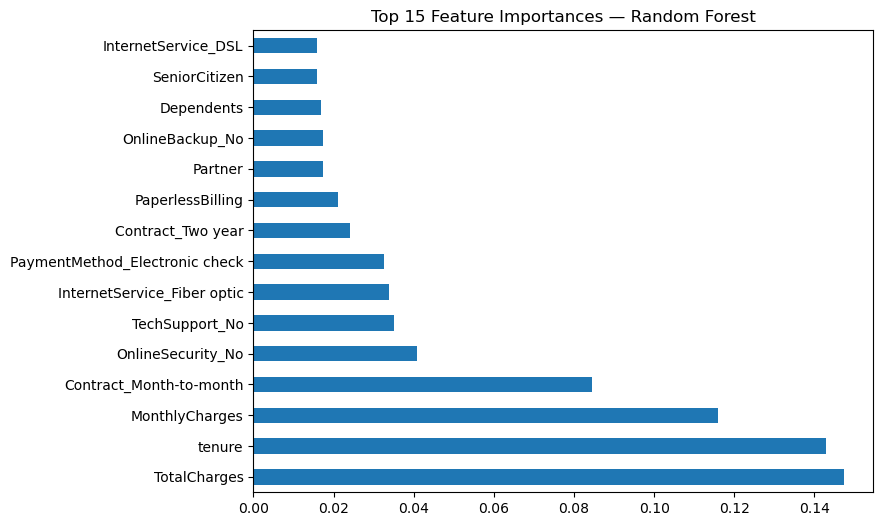

In [8]:
# Importance Plot
importances.head(15).plot(kind='barh', figsize=(8,6))
plt.title("Top 15 Feature Importances — Random Forest")
plt.show()

In [9]:
# Adding 'customerID' and Exporting Predictions
df_clean = pd.read_csv("../data/cleaned/cleaned_telco_churn.csv")

best_probs = y_prob_xgb

df_export = X_test.copy()

df_export['customerID'] = df_clean.loc[df_clean['original_index'].isin(X_test.index), 'customerID'].values

df_export['ActualChurn'] = y_test
df_export['PredictedProb'] = best_probs

df_export.to_csv("../data/modeling/churn_predictions_for_dashboard.csv", index=False)

# Summary

- Trained Logistic Regression, Random Forest, and XGBoost models
- Evaluated using precision, recall, F1, and ROC-AUC
- Identified best-performing model
- Extracted feature importance
- Exported churn probability predictions for Power BI dashboard